# Financial Performance and Budget Variance

**Author: Tajamul Khan**

Why did operating profit miss the plan?

Original synthetic teaching data. All outputs below are calculated by executing these cells. This is an analytical portfolio case study, not a real client engagement.

## Situation and task

Finance needs a reconciled bridge from planned operating profit to actual performance.

Compare revenue, cost of goods and operating expenses by month and business unit.

## Data contract and KPI definitions

One row per month, business unit and account. Operating profit = revenue − COGS − Opex. Positive favorable variance means actual revenue exceeds budget or actual expense is below budget. All amounts USD.

See `data/README.md` for field types, source and seed.

In [1]:
from pathlib import Path
import json, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
BASE = Path.cwd()
assert (BASE/'data/raw.csv').exists(), 'Run from this project directory'
OUT = BASE/'outputs'
OUT.mkdir(exist_ok=True)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False})
df = pd.read_csv(BASE/'data/raw.csv')
if 'date' in df:
    df['date'] = pd.to_datetime(df['date'])
print('Raw shape:',df.shape)
display(df.head())


Raw shape: (108, 5)


,date,business_unit,account,budget,actual
0,2025-01-01,Consumer,Revenue,135474.89,143447.18
1,2025-01-01,Consumer,COGS,80971.36,88491.78
2,2025-01-01,Consumer,Opex,39745.17,44801.95
3,2025-01-01,Business,Revenue,129507.72,125085.49
4,2025-01-01,Business,COGS,78322.09,79320.36


## Validate the source

Inspect missingness and grain before computing metrics. Missing outcomes are not automatically zeros.

In [2]:
audit=pd.DataFrame({'dtype':df.dtypes.astype(str),'missing':df.isna().sum(),'unique_values':df.nunique()})
display(audit)
print('Exact duplicate rows:',df.duplicated().sum())
audit.to_csv(OUT/'data_quality.csv')


Exact duplicate rows: 0


,dtype,missing,unique_values
date,datetime64[ns],0,12
business_unit,object,0,3
account,object,0,3
budget,float64,0,108
actual,float64,0,108


## Action: analysis

Unpivot accounts, apply account-specific favorable signs and reconcile the profit variance bridge.

In [3]:
assert not df.duplicated(['date','business_unit','account']).any()
df['favorable_variance']=np.where(df.account=='Revenue',df.actual-df.budget,df.budget-df.actual)
summary=df.groupby('account')[['budget','actual','favorable_variance']].sum()
sign=pd.Series({'Revenue':1,'COGS':-1,'Opex':-1})
actual_profit=(summary.actual*sign).sum();budget_profit=(summary.budget*sign).sum()
assert np.isclose(actual_profit-budget_profit,summary.favorable_variance.sum())
metrics={'Actual operating profit (USD)':actual_profit,'Budget operating profit (USD)':budget_profit,'Profit variance (USD)':actual_profit-budget_profit}
chart=summary.favorable_variance; ylabel='Favorable variance (USD)'

## Deep dive: Business-unit profit variance bridge

Reconcile business-unit profit differences to the total operating profit gap. Positive values are favorable for all accounts after sign adjustment.

Business has the least favorable profit variance (-34,260.44 USD). Review the account-level bridge and reconcile to the ledger before acting.
Out[4]: 142


account,COGS,Opex,Revenue,total_profit_variance
business_unit,,,,
Business,-28555.03,-20730.33,15024.92,-34260.44
Consumer,-64814.13,-26730.15,101042.52,9498.24
Enterprise,-16247.81,-7915.79,13411.50,-10752.10


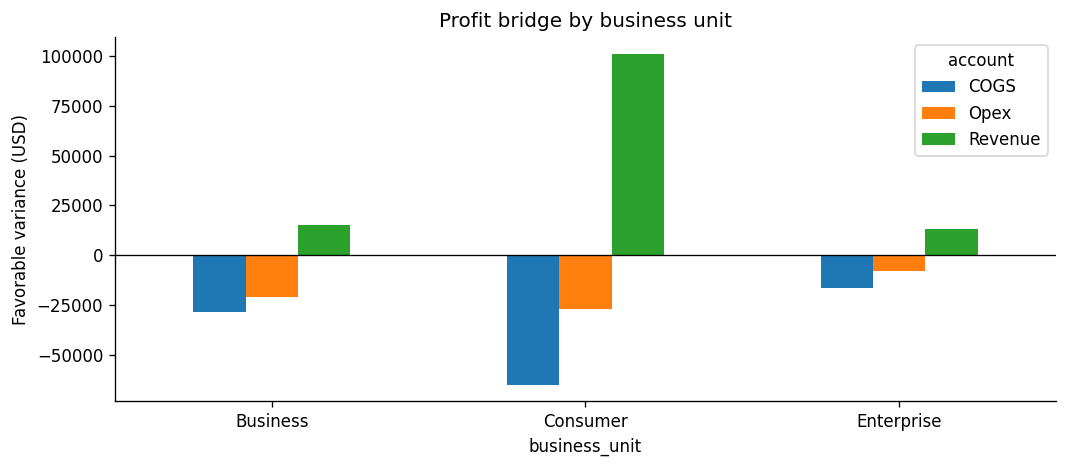

In [4]:

detail=df.groupby(['business_unit','account']).favorable_variance.sum().unstack('account');detail['total_profit_variance']=detail.sum(axis=1)
assert np.isclose(detail.total_profit_variance.sum(),actual_profit-budget_profit)
display(detail.round(2))
fig,ax=plt.subplots(figsize=(9,4));detail.drop(columns='total_profit_variance').plot.bar(ax=ax,rot=0);ax.axhline(0,color='black',lw=.8);ax.set_ylabel('Favorable variance (USD)');ax.set_title('Profit bridge by business unit');fig.tight_layout();fig.savefig(OUT/'detail.png');plt.show()
worst=detail.total_profit_variance.idxmin()
recommendation=f'{worst} has the least favorable profit variance ({detail.loc[worst,"total_profit_variance"]:,.2f} USD). Review the account-level bridge and reconcile to the ledger before acting.'

detail.to_csv(OUT/'detail.csv')
print(recommendation)
(OUT/'recommendation.txt').write_text(recommendation+'\n')


## Results: calculated evidence

These describe only the included synthetic dataset. They do not measure deployed impact.

In [5]:
display(summary.round(4))
display(pd.Series(metrics,name='value').to_frame())
summary.to_csv(OUT/'summary.csv')
(OUT/'metrics.json').write_text(json.dumps({k:float(v) for k,v in metrics.items()},indent=2))
df.to_csv(OUT/'analysis_ready.csv',index=False)
assert all(np.isfinite(float(v)) for v in metrics.values()), 'Invalid KPI'


,budget,actual,favorable_variance
account,,,
COGS,2917849.32,3027466.29,-109616.97
Opex,1516704.23,1572080.50,-55376.27
Revenue,5265006.52,5394485.46,129478.94


,value
Actual operating profit (USD),794938.67
Budget operating profit (USD),830452.97
Profit variance (USD),-35514.30


## SQL cross-check

Load validated facts into SQLite and reconcile shared aggregates against Python.

In [6]:
with sqlite3.connect(':memory:') as conn:
    df.to_sql('facts',conn,index=False,if_exists='replace')
    sql_result=pd.read_sql_query((BASE/'analysis.sql').read_text(),conn)
display(sql_result)
sql_result.to_csv(OUT/'sql_results.csv',index=False)
# Reconcile at least one common aggregate by group, rather than trusting the SQL output.
key=sql_result.columns[0]
py=summary.reset_index()
common=[c for c in sql_result.columns[1:] if c in py.columns]
assert common, 'No comparable aggregate'
joined=sql_result.merge(py,on=key,suffixes=('_sql','_python'),validate='one_to_one')
assert len(joined)==len(summary)==len(sql_result)
for col in common:
    assert np.allclose(joined[col+'_sql'],joined[col+'_python'],rtol=1e-8,atol=1e-6), col
print('SQL / Python reconciliation passed:',common)


SQL / Python reconciliation passed: ['budget', 'actual', 'favorable_variance']


,account,budget,actual,favorable_variance
0,COGS,2917849.32,3027466.29,-109616.97
1,Opex,1516704.23,1572080.50,-55376.27
2,Revenue,5265006.52,5394485.46,129478.94


## Visual interpretation

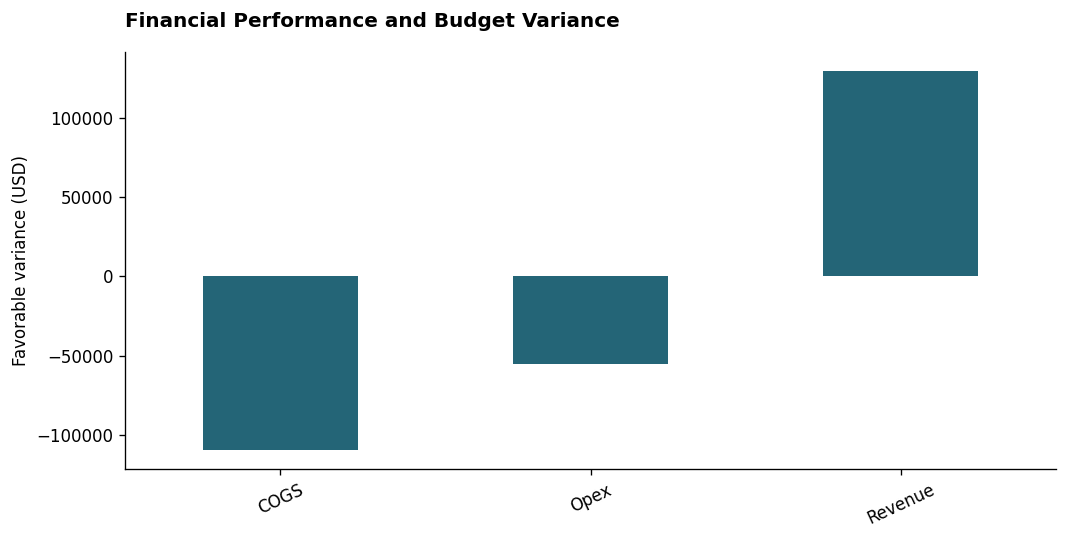

In [7]:
fig,ax=plt.subplots(figsize=(9,4.6))
chart.plot(kind='bar',ax=ax,color='#246577',rot=25)
ax.set_ylabel(ylabel)
ax.set_xlabel('')
ax.set_title('Financial Performance and Budget Variance',loc='left',fontweight='bold',pad=15)
fig.tight_layout()
fig.savefig(OUT/'overview.png',bbox_inches='tight')
plt.show()


## Offline dashboard

The KPI cards and chart are a fixed analysis snapshot. The row filter searches the summary table; it does not recompute the KPIs.

In [8]:
# Standalone dashboard: no remote JavaScript, server or account required.
import html, base64
cards=''.join('<article><span>'+html.escape(k)+'</span><strong>'+f'{v:,.4f}'+'</strong></article>' for k,v in metrics.items())
image=base64.b64encode((OUT/'overview.png').read_bytes()).decode()
table=summary.round(4).to_html(classes='data',border=0)
page='''<!doctype html><html lang="en"><meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1"><title>Financial Performance and Budget Variance</title>
<style>body{font:16px system-ui;margin:0;background:#f3f5f7;color:#172c3b}main{max-width:1100px;margin:auto;padding:36px}header{border-bottom:3px solid #246577;margin-bottom:24px}small{color:#51616c}.cards{display:flex;gap:14px;flex-wrap:wrap}article{background:white;padding:18px;border:1px solid #d7e0e5;flex:1;min-width:175px}strong{display:block;font-size:27px;margin-top:12px}img{max-width:100%;margin-top:24px}table{border-collapse:collapse;background:white;width:100%;font-size:14px}td,th{padding:12px;text-align:right;border-bottom:1px solid #d7e0e5}input{padding:12px;margin:20px 0;width:280px;max-width:90%}.scroll{overflow:auto}footer{margin-top:24px}</style>
<main><header><small>TAJAMUL KHAN · DATA ANALYST PORTFOLIO</small><h1>Financial Performance and Budget Variance</h1><p>Why did operating profit miss the plan?</p><p><b>Synthetic teaching data · Fictional 2025 case study</b></p></header><section class="cards">'''+cards+'''</section><img alt="Analysis overview chart" src="data:image/png;base64,'''+image+'''"><h2>Explore summary groups</h2><label for="filter">Filter summary rows</label><br><input id="filter" placeholder="Type a group name"><div class="scroll">'''+table+'''</div><p>This management-accounting simulation excludes tax, interest, accrual timing and currency translation.</p><footer>Instagram @tajamul.codes · linkedin.com/in/tajamulkhann/</footer></main>
<script>document.getElementById('filter').addEventListener('input',function(){const q=this.value.toLowerCase();document.querySelectorAll('tbody tr').forEach(r=>r.hidden=!r.textContent.toLowerCase().includes(q))});</script></html>'''
detail_image=base64.b64encode((OUT/'detail.png').read_bytes()).decode()
page=page.replace('<h2>Explore summary groups</h2>','<h2>Analyst finding</h2><p>'+html.escape(recommendation)+'</p><img alt="Supporting analysis" src="data:image/png;base64,'+detail_image+'"><h2>Explore summary groups</h2>')
(OUT/'dashboard.html').write_text(page)
print('Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.')


Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.


## Decision, limitations and next step

This management-accounting simulation excludes tax, interest, accrual timing and currency translation.

**Next step:** Add ledger reconciliation, account mapping controls and rolling forecasts.

Use the result table to identify a priority for investigation. Avoid claiming that the suggested action has already delivered a business improvement.

## Career discussion

Explain the business question, data grain, denominator, validation, strongest finding and one limitation. Use the README STAR story only after reproducing and understanding this project.